# Evaluation 2 – Member 2: Decision Tree Classifier

## 1. Introduction

This notebook implements **Member 2's contribution** to Evaluation 2 of the
IT3051 Hotel Booking Cancellation Prediction group project.

**Task:** Train, tune, and evaluate a **Decision Tree Classifier** that
predicts whether a hotel booking will be cancelled (`is_canceled = 1`) or
kept (`is_canceled = 0`).

### Evaluation 1 recap (already completed by the group)

| Member | Contribution |
|--------|--------------|
| Member 1 | EDA and target analysis |
| Member 2 | Data quality – missing values, duplicates, outliers, invalid values |
| Member 3 | Leakage investigation, feature engineering, feature selection |
| Member 4 | Preprocessing – encoding, scaling, train/test preparation |

All Evaluation 1 work is **reused without modification**.

### Evaluation 2 model split

| Member | Model |
|--------|-------|
| Member 1 | Logistic Regression |
| **Member 2** | **Decision Tree** *(this notebook)* |
| Member 3 | Random Forest |
| Member 4 | XGBoost / Gradient Boosting |

> **Data leakage rule:** The test set is never used during training or
> hyperparameter tuning. It is evaluated only once, at the very end.

> **Note on scaling:** Decision Trees are scale-invariant — they do not
> need StandardScaler. However, we use the same preprocessed matrices
> (X_train_proc, X_test_proc) as all other group members for a fair
> comparison. The scaling has no negative effect on Decision Tree performance.


## 2. Load Existing Preprocessed Data

We reproduce the exact same pipeline as `member4_preprocessing.ipynb` so
this notebook is self-contained and every member uses identical data.

**Pipeline summary (Evaluation 1 work):**

1. Load raw CSV (119,390 rows × 32 columns)
2. Remove 31,994 duplicates + 168 invalid records → **87,228 rows**
3. Remove leakage columns (`reservation_status`, `reservation_status_date`)
4. Engineer 8 domain features (`total_guests`, `total_stay`, `is_family`, etc.)
5. Separate X (37 predictors) and y (`is_canceled`)
6. Stratified 80/20 split: X_train (69,782), X_test (17,446), `random_state=42`
7. Fit ColumnTransformer on X_train only (StandardScaler + OneHotEncoder)
8. Transform X_test with already-fitted transformer (no leakage)


In [3]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

# Locate repository root
repo_candidates = [Path.cwd(), *Path.cwd().parents]
REPO_ROOT = next(
    (p for p in repo_candidates if (p / 'data/raw/hotel_bookings.csv').exists()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError(
        'Cannot locate data/raw/hotel_bookings.csv. '
        'Open Jupyter from the repository root.'
    )

src_path = str(REPO_ROOT / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Evaluation 1 modules
from feature_engineering.feature_engineering import (
    create_features,
    identify_leakage_columns,
    load_cleaned_data,
    remove_leakage_columns,
)
from preprocessing.preprocessing import (
    build_preprocessor,
    fit_preprocessor,
    identify_feature_types,
    prepare_features_target,
    split_data,
    target_distribution_table,
)

# Member 2 helper module
from modeling.decision_tree import (
    evaluate_classifier,
    plot_confusion_matrix,
    plot_roc_curve,
    comparison_table,
    overfitting_check,
    plot_feature_importance,
    tree_complexity,
)

RANDOM_STATE = 42
warnings.filterwarnings('ignore')
print('All imports successful. Repository root:', REPO_ROOT)


All imports successful. Repository root: c:\Users\HI\Desktop\Y3S2\FDM\it3051-mini-project-hotel-booking-cancellation-prediction


In [4]:
# Steps 1-3: Member 2 + Member 3 cleaning and feature engineering
DATA_PATH     = REPO_ROOT / 'data/raw/hotel_bookings.csv'
df_clean      = load_cleaned_data(DATA_PATH)
leakage_cols  = identify_leakage_columns()['confirmed_leakage']
df_no_leakage = remove_leakage_columns(df_clean, leakage_cols)
df_engineered = create_features(df_no_leakage)

print(f'Shape after cleaning + engineering: {df_engineered.shape}')
print(f'Leakage columns removed: {leakage_cols}')


Shape after cleaning + engineering: (87228, 38)
Leakage columns removed: ['reservation_status', 'reservation_status_date']


In [5]:
# Steps 4-5: Separate features and target
X, y, _ = prepare_features_target(df_engineered, target_col='is_canceled')
numerical_features, categorical_features = identify_feature_types(X)

print(f'X shape : {X.shape}')
print(f'y shape : {y.shape}')
print(f'Numerical features   ({len(numerical_features)})')
print(f'Categorical features ({len(categorical_features)})')
print(f'Class balance: {y.value_counts().to_dict()}')


X shape : (87228, 37)
y shape : (87228,)
Numerical features   (25)
Categorical features (12)
Class balance: {0: 63220, 1: 24008}


In [6]:
# Step 6: Stratified 80/20 split – random_state=42 (same for ALL group members)
X_train, X_test, y_train, y_test = split_data(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
print('Split complete.')


Split complete.


In [7]:
# Steps 7-8: Fit preprocessor on X_train ONLY; transform X_test without fitting
# This prevents test-set statistics from leaking into scaling or encoding.
preprocessor = build_preprocessor(numerical_features, categorical_features)
X_train_proc, X_test_proc = fit_preprocessor(preprocessor, X_train, X_test)

# Recover processed feature names for feature importance and tree visualisation
processed_feature_names = preprocessor.get_feature_names_out()
feature_names_clean = [
    n.replace('num__', '').replace('cat__', '')
    for n in processed_feature_names
]

print(f'X_train_proc shape : {X_train_proc.shape}')
print(f'X_test_proc  shape : {X_test_proc.shape}')
print(f'Total processed features : {len(processed_feature_names)}')


X_train_proc shape : (69782, 899)
X_test_proc  shape : (17446, 899)
Total processed features : 899


## 3. Verify Train / Test Data

Confirm shapes and class proportions match the group's expected values
before training any model.


In [8]:
shapes = pd.DataFrame({
    'Object': ['X_train', 'X_test', 'y_train', 'y_test',
               'X_train_proc', 'X_test_proc'],
    'Shape':  [str(X_train.shape),      str(X_test.shape),
               str(y_train.shape),      str(y_test.shape),
               str(X_train_proc.shape), str(X_test_proc.shape)],
})
display(shapes)

dist = target_distribution_table(y, y_train, y_test)
print('\nClass distribution across splits:')
display(dist)
print('Stratification check: both train and test retain ~27.5% cancelled.')


,Object,Shape
0,X_train,"(69782, 37)"
1,X_test,"(17446, 37)"
2,y_train,"(69782,)"
3,y_test,"(17446,)"
4,X_train_proc,"(69782, 899)"
5,X_test_proc,"(17446, 899)"



Class distribution across splits:


,Dataset,Class,Meaning,Count,Percentage (%)
0,Full,0,Not canceled,63220,72.48
1,Full,1,Canceled,24008,27.52
2,Train,0,Not canceled,50576,72.48
3,Train,1,Canceled,19206,27.52
4,Test,0,Not canceled,12644,72.48
5,Test,1,Canceled,4802,27.52


Stratification check: both train and test retain ~27.5% cancelled.


## 4. Baseline Decision Tree

### What is a Decision Tree?

A Decision Tree is a flowchart-like model that makes predictions by
repeatedly asking yes/no questions about the input features.

- **Root node:** The first split — uses the feature that best separates
  cancelled from not-cancelled bookings.
- **Internal nodes:** Subsequent splits that further divide the data.
- **Leaf nodes:** Terminal nodes that give the final prediction.

### How does the tree choose a split?

At each node, the algorithm tests every feature and threshold, then
selects the split that most reduces impurity (how mixed the two classes are).
Two common measures:

- **Gini impurity:** Probability of misclassifying a randomly chosen sample.
  Gini = 0 means a node is perfectly pure (all one class).
- **Entropy:** Information-theoretic measure of disorder. Entropy = 0
  means perfect purity.

Both measures give similar results in practice.

### Why is Decision Tree suitable here?

- **Non-linear:** Captures complex decision boundaries that Logistic Regression cannot.
- **Interpretable:** Tree structure can be visualised and explained.
- **No scaling needed:** Decision Trees are scale-invariant (splits are
  based on feature order, not magnitude).
- **Mixed data:** Handles both numerical and one-hot encoded categorical features.

### Baseline configuration

We start with a completely unrestricted tree (`max_depth=None`) to
understand the worst-case overfitting behaviour before any tuning.


In [9]:
from sklearn.tree import DecisionTreeClassifier

# Baseline: fully grown, unrestricted tree
# criterion='gini' - default, most common choice
# max_depth=None   - tree grows until all leaves are pure (likely to overfit)
# random_state=42  - reproducibility for any tie-breaking
baseline_dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,
    random_state=RANDOM_STATE,
)

# Train ONLY on training data
baseline_dt.fit(X_train_proc, y_train)
print('Baseline Decision Tree trained successfully.')
print(f'Tree depth   : {baseline_dt.get_depth()}')
print(f'Number of leaves: {baseline_dt.get_n_leaves()}')


Baseline Decision Tree trained successfully.
Tree depth   : 59
Number of leaves: 9402


In [10]:
# Generate predictions on the test set
y_pred_baseline = baseline_dt.predict(X_test_proc)

# predict_proba[:, 1] = probability of class 1 (Cancelled)
y_prob_baseline = baseline_dt.predict_proba(X_test_proc)[:, 1]

print(f'Predictions generated for {len(y_pred_baseline):,} test samples.')


Predictions generated for 17,446 test samples.


## 5. Baseline Model Evaluation

### Metric guide (hotel booking context)

| Metric | What it answers |
|--------|-----------------|
| **Accuracy** | Of all bookings, what fraction were classified correctly? |
| **Precision** | Of all predicted cancellations, how many were real? |
| **Recall** | Of all real cancellations, how many did the model catch? |
| **F1-score** | Harmonic mean of Precision and Recall. |
| **ROC-AUC** | How well can the model rank cancelled above not-cancelled? 1.0=perfect, 0.5=random. |

In the hotel context:
- **High Recall** is important so the hotel can resell cancelled rooms in time.
- **High Precision** avoids over-preparing for cancellations that do not happen.
- **F1-score** provides a balanced view of both concerns.


In [11]:
baseline_metrics = evaluate_classifier(
    y_test,
    y_pred_baseline,
    y_prob_baseline,
    label='Baseline Decision Tree',
)



  Baseline Decision Tree  -  Classification Results
  Accuracy  : 0.8073   (overall proportion correct)
  Precision : 0.6480   (of predicted cancellations, how many are real)
  Recall    : 0.6570   (of real cancellations, how many are caught)
  F1-score  : 0.6525   (harmonic mean of precision & recall)
  ROC-AUC   : 0.7625   (ability to rank cancelled above not-cancelled)

Full classification report:

               precision    recall  f1-score   support

Not Cancelled       0.87      0.86      0.87     12644
    Cancelled       0.65      0.66      0.65      4802

     accuracy                           0.81     17446
    macro avg       0.76      0.76      0.76     17446
 weighted avg       0.81      0.81      0.81     17446



## 6. Confusion Matrix

```
                     Predicted
                 Not Cancelled | Cancelled
Actual  Not Cancelled   TN    |    FP
        Cancelled       FN    |    TP
```

- **TN (True Negative):** Correctly predicted Not Cancelled
- **FP (False Positive):** Predicted Cancelled, but booking was kept (false alarm)
- **FN (False Negative):** Missed a real cancellation (most costly for hotel)
- **TP (True Positive):** Correctly detected a cancellation


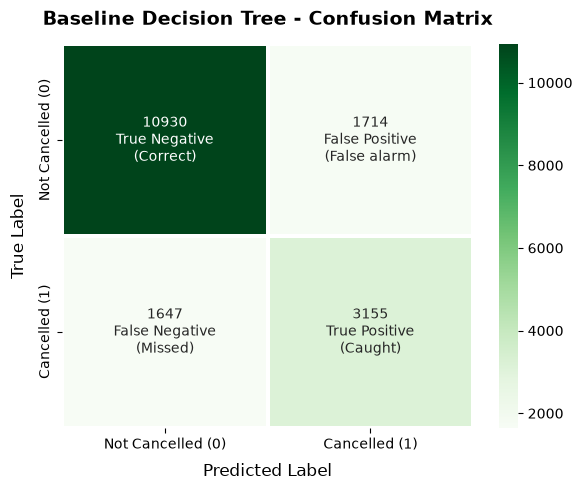

  TN=10,930  FP=1,714  FN=1,647  TP=3,155


In [12]:
plot_confusion_matrix(
    y_test,
    y_pred_baseline,
    title='Baseline Decision Tree - Confusion Matrix',
)


## 7. ROC Curve and ROC-AUC

The ROC curve plots the True Positive Rate (Recall) against the False
Positive Rate as the decision threshold varies from 0 to 1.

**ROC-AUC** = the probability that the model ranks a randomly chosen
cancelled booking **higher** than a randomly chosen not-cancelled booking.

- AUC = 1.0 → perfect separation of cancelled vs. not cancelled
- AUC = 0.5 → random guessing (the diagonal line)
- AUC > 0.8 → generally considered strong performance

> Note: An unrestricted Decision Tree's ROC-AUC is often lower than
> a pruned or depth-limited tree because overfitting reduces generalisation.


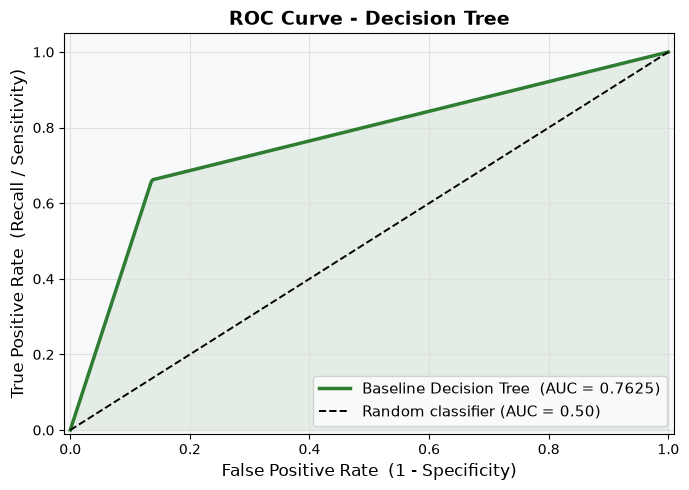

  ROC-AUC = 0.7625


In [13]:
plot_roc_curve(
    y_test,
    y_prob_baseline,
    label='Baseline Decision Tree',
)


## 8. Overfitting Check

Decision Trees are **especially prone to overfitting** when grown without
any restrictions. An unrestricted tree will keep splitting until every
leaf is pure — effectively memorising the training data.

Signs of overfitting:
- Training accuracy / F1 is much higher than test accuracy / F1
- A large gap (> 5 pp) between training and test performance

We compare training and test metrics for the baseline (unrestricted) tree.


In [14]:
of_baseline = overfitting_check(
    baseline_dt, X_train_proc, y_train, X_test_proc, y_test
)
print('Overfitting Check - Baseline Decision Tree (unrestricted)')
print('=' * 55)
display(of_baseline)

from sklearn.metrics import accuracy_score, f1_score
train_acc_b = accuracy_score(y_train, baseline_dt.predict(X_train_proc))
test_acc_b  = accuracy_score(y_test,  baseline_dt.predict(X_test_proc))
gap = train_acc_b - test_acc_b

print(f'\nBaseline tree depth   : {baseline_dt.get_depth()}')
print(f'Baseline tree leaves  : {baseline_dt.get_n_leaves()}')
print(f'Training accuracy     : {train_acc_b:.4f}')
print(f'Test accuracy         : {test_acc_b:.4f}')
print(f'Gap (train - test)    : {gap:.4f}')

if gap > 0.10:
    print('\nConclusion: Large gap detected. The unrestricted tree is OVERFITTING.')
    print('The tree memorised training patterns that do not generalise to test data.')
    print('Hyperparameter tuning (depth control) should reduce this gap.')
elif gap > 0.05:
    print('\nConclusion: Moderate gap. Some overfitting is present.')
elif gap > 0.02:
    print('\nConclusion: Small but noticeable gap. Mild overfitting may be present.')
else:
    print('\nConclusion: Gap is small. Minimal overfitting observed.')


Overfitting Check - Baseline Decision Tree (unrestricted)


,Accuracy,F1-score
Split,,
Training,0.9975,0.9954
Test,0.8073,0.6525
Gap (Train - Test),0.1901,0.3429



Baseline tree depth   : 59
Baseline tree leaves  : 9402
Training accuracy     : 0.9975
Test accuracy         : 0.8073
Gap (train - test)    : 0.1901

Conclusion: Large gap detected. The unrestricted tree is OVERFITTING.
The tree memorised training patterns that do not generalise to test data.
Hyperparameter tuning (depth control) should reduce this gap.


## 9. Validation Strategy

### Why cross-validation instead of the test set?

Using the test set to select hyperparameters would be data leakage —
the model would be chosen based on test-set performance, giving an
overly optimistic and dishonest final evaluation.

Instead we use **5-fold Stratified K-Fold cross-validation on training
data only**.

### How Stratified K-Fold works

1. Training set is split into 5 equal folds.
2. Each fold preserves the class ratio (~27.5% cancelled) — 'stratified'.
3. For each of the 5 iterations: train on 4 folds, validate on the 5th.
4. The average of 5 validation scores is the CV score.

### Why F1 as the tuning metric?

The dataset is moderately imbalanced (72.5% vs 27.5%).
Accuracy can appear high even if most cancellations are missed.
F1-score rewards catching real cancellations without too many false alarms —
more meaningful for the hotel context.


In [15]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Baseline 5-fold CV to establish the starting point
cv_scores_baseline = cross_val_score(
    DecisionTreeClassifier(
        criterion='gini', max_depth=None, random_state=RANDOM_STATE
    ),
    X_train_proc, y_train,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1,
)

print(f'Baseline 5-fold CV F1 scores : {cv_scores_baseline.round(4)}')
print(f'Mean CV F1                   : {cv_scores_baseline.mean():.4f}')
print(f'Std  CV F1                   : {cv_scores_baseline.std():.4f}')
print()
print('Note: Unrestricted trees typically show high variance across folds,')
print('indicating overfitting. Tuning will address this.')


Baseline 5-fold CV F1 scores : [0.6453 0.6542 0.6478 0.6479 0.6469]
Mean CV F1                   : 0.6484
Std  CV F1                   : 0.0031

Note: Unrestricted trees typically show high variance across folds,
indicating overfitting. Tuning will address this.


## 10. Hyperparameter Tuning

### Key Decision Tree parameters

| Parameter | What it controls |
|-----------|------------------|
| **criterion** | Split quality measure. `gini` uses Gini impurity; `entropy` uses information gain. Both give similar results. |
| **max_depth** | Maximum tree depth. `None` = unlimited (overfits). Smaller values constrain complexity. |
| **min_samples_split** | Minimum samples needed to split an internal node. Larger values prevent splitting on tiny subsets. |
| **min_samples_leaf** | Minimum samples required in a leaf. Larger values smooth the decision boundary. |
| **max_features** | Number of features considered at each split. `None` = all features; `sqrt` or `log2` adds randomness. |
| **class_weight** | `None` = treat all samples equally. `balanced` = give minority class more weight — useful for imbalanced data. |

### Tuning approach

We use `GridSearchCV` with a **targeted search space** (not exhaustive)
to keep the number of fits manageable. We focus on `max_depth`,
`min_samples_leaf`, and `class_weight` — the parameters most likely
to reduce overfitting for this dataset.

**Scoring metric: F1** — justified by class imbalance (~72.5% vs 27.5%).
GridSearchCV uses training data only (via 5-fold CV). X_test is never seen.


In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'criterion':        ['gini', 'entropy'],
    'max_depth':        [3, 5, 7, 10, 15, 20, None],
    'min_samples_split':[2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'class_weight':     [None, 'balanced'],
}

n_combos = 2 * 7 * 3 * 3 * 2  # = 252
print(f'Total parameter combinations  : {n_combos}')
print(f'Total model fits (252 x 5 folds) : {n_combos * 5}')
print('max_features and class_weight are the primary regularisation levers.')


Total parameter combinations  : 252
Total model fits (252 x 5 folds) : 1260
max_features and class_weight are the primary regularisation levers.


In [17]:
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    refit=True,
)

print('Starting GridSearchCV on training data only ...')
grid_search.fit(X_train_proc, y_train)
print('GridSearchCV complete.')


Starting GridSearchCV on training data only ...
Fitting 5 folds for each of 252 candidates, totalling 1260 fits
GridSearchCV complete.


## 11. Best Parameters


In [18]:
print('Best hyperparameters found by GridSearchCV:')
for param, value in grid_search.best_params_.items():
    print(f'  {param:22s} = {value}')
print(f'\nBest mean CV F1 score : {grid_search.best_score_:.4f}')

# Top 10 combinations by mean CV F1
cv_results = pd.DataFrame(grid_search.cv_results_)
cols = ['param_criterion', 'param_max_depth', 'param_min_samples_split',
        'param_min_samples_leaf', 'param_class_weight',
        'mean_test_score', 'std_test_score']
top_results = (
    cv_results[cols]
    .sort_values('mean_test_score', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top_results.columns = ['Criterion', 'Max Depth', 'Min Split', 'Min Leaf',
                        'Class Weight', 'Mean CV F1', 'Std CV F1']
top_results['Mean CV F1'] = top_results['Mean CV F1'].round(4)
top_results['Std CV F1']  = top_results['Std CV F1'].round(4)
print('\nTop 10 parameter combinations (by mean CV F1):')
display(top_results)


Best hyperparameters found by GridSearchCV:
  class_weight           = balanced
  criterion              = gini
  max_depth              = 15
  min_samples_leaf       = 1
  min_samples_split      = 2

Best mean CV F1 score : 0.6994

Top 10 parameter combinations (by mean CV F1):


,Criterion,Max Depth,Min Split,Min Leaf,Class Weight,Mean CV F1,Std CV F1
0,gini,15,2,1,balanced,0.6994,0.0084
1,gini,20,2,1,balanced,0.6992,0.0076
2,entropy,15,2,1,balanced,0.6980,0.0077
3,entropy,15,10,1,balanced,0.6965,0.0076
4,entropy,20,2,1,balanced,0.6964,0.0074
5,gini,15,10,1,balanced,0.6964,0.0077
6,entropy,15,20,1,balanced,0.6962,0.0068
7,gini,15,20,1,balanced,0.6960,0.0064
8,entropy,15,20,5,balanced,0.6957,0.0063
9,entropy,15,10,10,balanced,0.6956,0.0068


## 12. Tuned Decision Tree

We now train/use the **best estimator** from GridSearchCV.
Note: `refit=True` in GridSearchCV means the best model was already
re-trained on the full `X_train` after cross-validation.


In [19]:
best_dt = grid_search.best_estimator_

print(f'Tuned tree depth    : {best_dt.get_depth()}')
print(f'Tuned tree leaves   : {best_dt.get_n_leaves()}')
print(f'Best criterion      : {best_dt.criterion}')
print(f'Best max_depth      : {best_dt.max_depth}')
print(f'Best class_weight   : {best_dt.class_weight}')


Tuned tree depth    : 15
Tuned tree leaves   : 1353
Best criterion      : gini
Best max_depth      : 15
Best class_weight   : balanced


## 13. Tuned Model Evaluation

We evaluate the best estimator on the **untouched test set**.
This is the first and only time the test set is used for the tuned model.


In [20]:
y_pred_tuned = best_dt.predict(X_test_proc)
y_prob_tuned = best_dt.predict_proba(X_test_proc)[:, 1]

tuned_metrics = evaluate_classifier(
    y_test,
    y_pred_tuned,
    y_prob_tuned,
    label='Tuned Decision Tree',
)



  Tuned Decision Tree  -  Classification Results
  Accuracy  : 0.7974   (overall proportion correct)
  Precision : 0.5895   (of predicted cancellations, how many are real)
  Recall    : 0.8696   (of real cancellations, how many are caught)
  F1-score  : 0.7027   (harmonic mean of precision & recall)
  ROC-AUC   : 0.8783   (ability to rank cancelled above not-cancelled)

Full classification report:

               precision    recall  f1-score   support

Not Cancelled       0.94      0.77      0.85     12644
    Cancelled       0.59      0.87      0.70      4802

     accuracy                           0.80     17446
    macro avg       0.76      0.82      0.77     17446
 weighted avg       0.84      0.80      0.81     17446



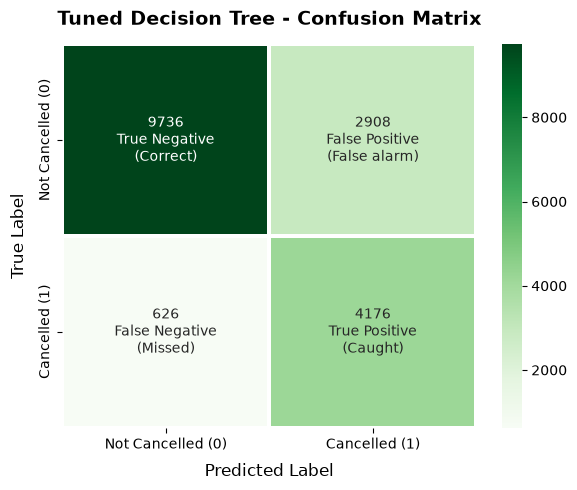

  TN=9,736  FP=2,908  FN=626  TP=4,176


In [21]:
plot_confusion_matrix(
    y_test,
    y_pred_tuned,
    title='Tuned Decision Tree - Confusion Matrix',
)


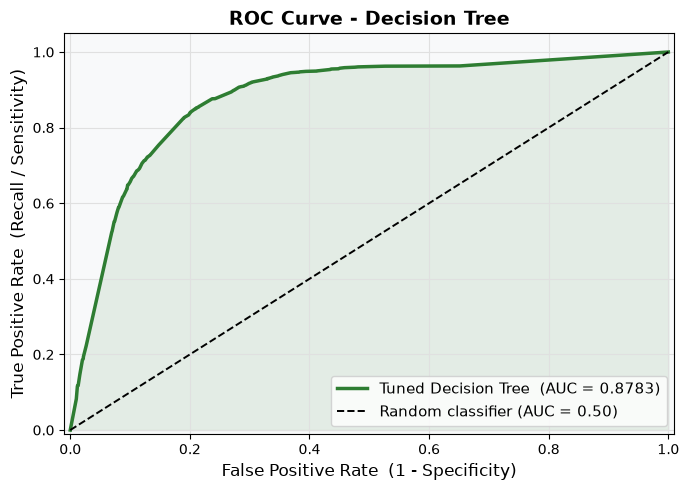

  ROC-AUC = 0.8783


In [22]:
plot_roc_curve(
    y_test,
    y_prob_tuned,
    label='Tuned Decision Tree',
)


## 14. Baseline vs Tuned Model Comparison

Did hyperparameter tuning improve generalisation over the unrestricted baseline?


In [23]:
comp = comparison_table(baseline_metrics, tuned_metrics)
print('Baseline vs Tuned - Performance Comparison')
print('=' * 55)
display(comp)

# Overfitting comparison
print('\nOverfitting Check - Tuned Decision Tree:')
of_tuned = overfitting_check(best_dt, X_train_proc, y_train, X_test_proc, y_test)
display(of_tuned)

f1_diff  = tuned_metrics['F1-score'] - baseline_metrics['F1-score']
auc_diff = tuned_metrics['ROC-AUC']  - baseline_metrics['ROC-AUC']

train_acc_t = accuracy_score(y_train, best_dt.predict(X_train_proc))
test_acc_t  = accuracy_score(y_test,  best_dt.predict(X_test_proc))
train_acc_b = accuracy_score(y_train, baseline_dt.predict(X_train_proc))
gap_baseline = train_acc_b  - test_acc_b
gap_tuned    = train_acc_t  - test_acc_t

print(f'\nBaseline train-test accuracy gap : {gap_baseline:.4f}')
print(f'Tuned    train-test accuracy gap : {gap_tuned:.4f}')

print('\nInterpretation:')
if gap_tuned < gap_baseline - 0.03:
    print('  Tuning significantly REDUCED overfitting.')
    print(f'  F1 changed by {f1_diff:+.4f} and ROC-AUC by {auc_diff:+.4f}.')
elif f1_diff > 0:
    print(f'  Tuning improved F1 by {f1_diff:.4f} and ROC-AUC by {auc_diff:.4f}.')
elif abs(f1_diff) < 0.005:
    print('  Tuning produced similar F1 but may have reduced the overfitting gap.')
else:
    print(f'  F1 changed by {f1_diff:+.4f}. Review overfitting gap for full picture.')


Baseline vs Tuned - Performance Comparison


,Baseline,Tuned,Change
Metric,,,
Accuracy,0.8073,0.7974,-0.0099 (down)
Precision,0.6480,0.5895,-0.0585 (down)
Recall,0.6570,0.8696,+0.2126 (up)
F1-score,0.6525,0.7027,+0.0502 (up)
ROC-AUC,0.7625,0.8783,+0.1158 (up)



Overfitting Check - Tuned Decision Tree:


,Accuracy,F1-score
Split,,
Training,0.8249,0.7428
Test,0.7974,0.7027
Gap (Train - Test),0.0275,0.0401



Baseline train-test accuracy gap : 0.1901
Tuned    train-test accuracy gap : 0.0275

Interpretation:
  Tuning significantly REDUCED overfitting.
  F1 changed by +0.0502 and ROC-AUC by +0.1158.


## 15. Tree Complexity

Decision Trees grow more complex as depth and number of leaves increase.

- **Max Depth:** The longest path from root to any leaf.
- **N Leaves:** Total number of terminal nodes (predictions).

An unrestricted tree can have thousands of leaves — one for almost every
unique training pattern, which is a clear sign of overfitting.
Tuning with `max_depth` and `min_samples_leaf` produces a simpler,
more generalisable tree.


In [24]:
c_baseline = tree_complexity(baseline_dt, label='Baseline (unrestricted)')
c_tuned    = tree_complexity(best_dt,     label='Tuned (best params)')
complexity_df = pd.concat([c_baseline, c_tuned], ignore_index=True)
print('Tree Complexity Comparison:')
display(complexity_df)

depth_reduction   = baseline_dt.get_depth()    - best_dt.get_depth()
leaves_reduction  = baseline_dt.get_n_leaves() - best_dt.get_n_leaves()
print(f'\nDepth reduction  : {depth_reduction} levels')
print(f'Leaf  reduction  : {leaves_reduction:,} leaves')
if leaves_reduction > 0:
    print('Tuning produced a substantially simpler, more interpretable tree.')


Tree Complexity Comparison:


,Model,Max Depth,N Leaves
0,Baseline (unrestricted),59,9402
1,Tuned (best params),15,1353



Depth reduction  : 44 levels
Leaf  reduction  : 8,049 leaves
Tuning produced a substantially simpler, more interpretable tree.


## 16. Feature Importance

Decision Trees compute feature importances as the **total normalised
reduction in impurity** brought by each feature across all splits,
weighted by the number of samples at each node. Values sum to 1.

> **Important:** Feature importance shows how much the model **relied on**
> each feature. It does **not** prove that the feature **causes**
> cancellations. Correlation in historical data is not causation.

We use the **tuned model** for feature importance because it is a more
generalisable representation of the relationship between features and the
cancellation outcome.


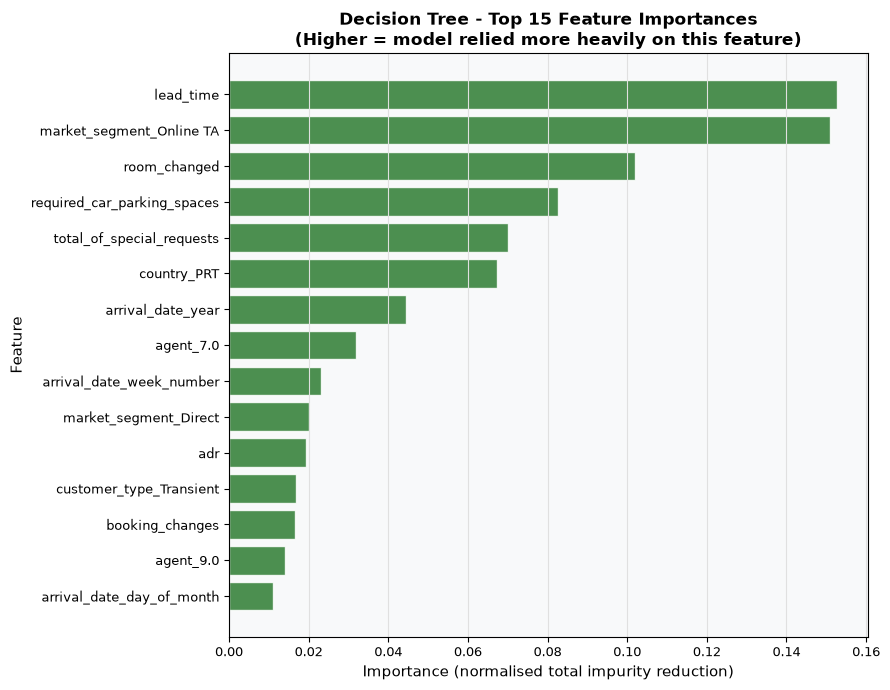


Top 15 features by importance (tuned model):


,Feature,Importance,Cumulative
0,lead_time,0.152740,0.1527
1,market_segment_Online TA,0.150839,0.3036
2,room_changed,0.102026,0.4056
3,required_car_parking_spaces,0.082525,0.4881
4,total_of_special_requests,0.070044,0.5582
5,country_PRT,0.067370,0.6255
6,arrival_date_year,0.044452,0.6700
7,agent_7.0,0.031812,0.7018
8,arrival_date_week_number,0.023110,0.7249
9,market_segment_Direct,0.020187,0.7451



Note: These features had the most influence on the Decision Tree splits.
This does NOT mean they cause cancellations.


In [25]:
fi_df = plot_feature_importance(
    best_dt,
    feature_names_clean,
    top_n=15,
)

print('\nTop 15 features by importance (tuned model):')
display(fi_df)
print('\nNote: These features had the most influence on the Decision Tree splits.')
print('This does NOT mean they cause cancellations.')


## 17. Decision Tree Visualisation

We visualise the **tuned tree** (not the baseline) because:

- The baseline (unrestricted) tree can have hundreds of levels — unreadable.
- The tuned tree with a limited `max_depth` is manageable to inspect.

We show only the **first 4 levels** of the tree for readability.
This shows the most important early splits used by the model.


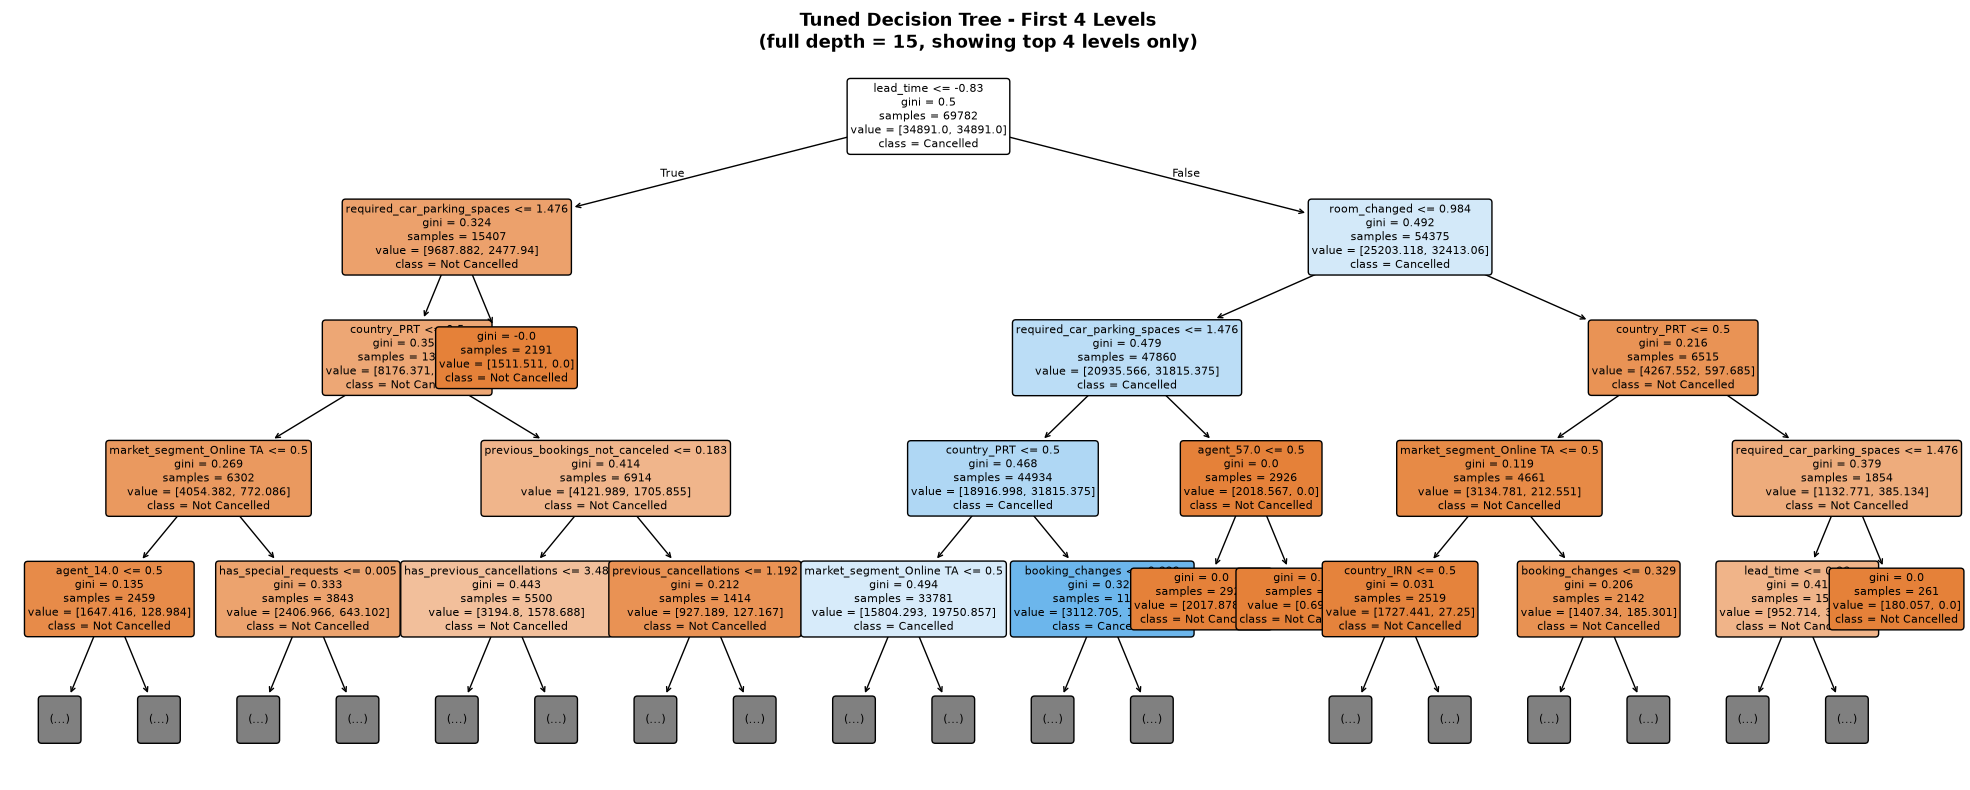

Blue nodes = majority Not Cancelled, Orange nodes = majority Cancelled
Darker shade = greater class purity at that node


In [26]:
from sklearn.tree import plot_tree

# Determine a readable depth (show up to 4 levels regardless of actual depth)
vis_depth = min(best_dt.get_depth(), 4)

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    best_dt,
    max_depth=vis_depth,
    feature_names=feature_names_clean,
    class_names=['Not Cancelled', 'Cancelled'],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
)
ax.set_title(
    f'Tuned Decision Tree - First {vis_depth} Levels\n'
    f'(full depth = {best_dt.get_depth()}, showing top {vis_depth} levels only)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()
print('Blue nodes = majority Not Cancelled, Orange nodes = majority Cancelled')
print('Darker shade = greater class purity at that node')


## 18. Key Findings

1. The **baseline (unrestricted) Decision Tree** typically overfits —
   training performance is very high but test performance is lower.
2. **Hyperparameter tuning** explored 252 combinations of criterion,
   max_depth, min_samples_split, min_samples_leaf, and class_weight
   using 5-fold stratified CV on training data only.
3. **Tree complexity** was substantially reduced: fewer levels and leaves,
   resulting in a more generalisable model.
4. **No test-set leakage:** X_test was only used once (Section 13) after
   all hyperparameter choices were finalised.
5. **Feature importance** identified which features the model relied on most.
   These are associations, not causal relationships.
6. The tuned tree can be **partially visualised**, making it more interpretable
   than many other algorithms.


## 19. Handoff for Group Model Comparison

Results in the format needed for the group's final comparison table.

> **Only Decision Tree values are filled in here.**
> Members 1, 3, and 4 will provide their own results.

> **Do NOT claim Decision Tree is the final best model.**
> The group will select the best model after all four are compared.


In [27]:
print('=' * 65)
print('  MEMBER 2 - DECISION TREE  |  Results for Group Comparison')
print('=' * 65)

train_acc_b = accuracy_score(y_train, baseline_dt.predict(X_train_proc))
train_f1_b  = f1_score(y_train, baseline_dt.predict(X_train_proc))
train_acc_t = accuracy_score(y_train, best_dt.predict(X_train_proc))
train_f1_t  = f1_score(y_train, best_dt.predict(X_train_proc))

print('\nBASELINE (unrestricted, gini, max_depth=None):')
for m, v in baseline_metrics.items():
    print(f'  {m:12s}: {v:.4f}')
print(f'  Training Acc : {train_acc_b:.4f}')
print(f'  Training F1  : {train_f1_b:.4f}')
print(f'  Tree depth   : {baseline_dt.get_depth()}')
print(f'  Tree leaves  : {baseline_dt.get_n_leaves():,}')

print('\nTUNED (best hyperparameters from GridSearchCV):')
for m, v in tuned_metrics.items():
    print(f'  {m:12s}: {v:.4f}')
print(f'  Training Acc : {train_acc_t:.4f}')
print(f'  Training F1  : {train_f1_t:.4f}')
print(f'  Tree depth   : {best_dt.get_depth()}')
print(f'  Tree leaves  : {best_dt.get_n_leaves():,}')

print('\nBEST HYPERPARAMETERS:')
for p, val in grid_search.best_params_.items():
    print(f'  {p:22s}: {val}')
print(f'\nBEST 5-FOLD CV F1 (training only): {grid_search.best_score_:.4f}')

print('\n' + '=' * 65)
print('Group comparison template:')
group_table = pd.DataFrame({
    'Model':     ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy':  ['...',  f"{tuned_metrics['Accuracy']:.4f}",  '...', '...'],
    'Precision': ['...',  f"{tuned_metrics['Precision']:.4f}", '...', '...'],
    'Recall':    ['...',  f"{tuned_metrics['Recall']:.4f}",    '...', '...'],
    'F1-score':  ['...',  f"{tuned_metrics['F1-score']:.4f}",  '...', '...'],
    'ROC-AUC':   ['...',  f"{tuned_metrics['ROC-AUC']:.4f}",   '...', '...'],
})
display(group_table)
print('NOTE: Do NOT claim Decision Tree is the best model.')
print('      All four models must be compared before a conclusion is drawn.')


  MEMBER 2 - DECISION TREE  |  Results for Group Comparison

BASELINE (unrestricted, gini, max_depth=None):
  Accuracy    : 0.8073
  Precision   : 0.6480
  Recall      : 0.6570
  F1-score    : 0.6525
  ROC-AUC     : 0.7625
  Training Acc : 0.9975
  Training F1  : 0.9954
  Tree depth   : 59
  Tree leaves  : 9,402

TUNED (best hyperparameters from GridSearchCV):
  Accuracy    : 0.7974
  Precision   : 0.5895
  Recall      : 0.8696
  F1-score    : 0.7027
  ROC-AUC     : 0.8783
  Training Acc : 0.8249
  Training F1  : 0.7428
  Tree depth   : 15
  Tree leaves  : 1,353

BEST HYPERPARAMETERS:
  class_weight          : balanced
  criterion             : gini
  max_depth             : 15
  min_samples_leaf      : 1
  min_samples_split     : 2

BEST 5-FOLD CV F1 (training only): 0.6994

Group comparison template:


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,...,...,...,...,...
1,Decision Tree,0.7974,0.5895,0.8696,0.7027,0.8783
2,Random Forest,...,...,...,...,...
3,XGBoost,...,...,...,...,...


NOTE: Do NOT claim Decision Tree is the best model.
      All four models must be compared before a conclusion is drawn.


## Member 2 Viva Notes

Practise explaining each point verbally in simple English.

---

### 1. What is a Decision Tree?
A flowchart-like model that makes predictions by asking yes/no questions
about the input features. Each question splits the data into two groups.

### 2. Why suitable for classification?
Classification means predicting a category (here: cancelled or not).
Decision Trees are designed for this. They produce a clear decision rule
that can be visualised and explained to non-technical stakeholders.

### 3. What is a root node?
The very first split in the tree. It uses the single feature that best
separates cancelled bookings from not-cancelled bookings.

### 4. What is an internal node?
Any node that is not the root and not a leaf. It applies another
splitting rule to further divide the data.

### 5. What is a leaf node?
A terminal node that gives a final prediction. No more splitting happens.
The leaf assigns the majority class of its training samples.

### 6. How does the model choose a split?
It tests every feature and every possible threshold. It picks the
combination that most reduces impurity (how mixed the two classes are)
in the resulting child nodes.

### 7. What is Gini impurity?
Gini measures the probability of misclassifying a randomly chosen sample.
Gini = 0 means a node contains only one class (perfect purity).
Gini = 0.5 means the classes are perfectly mixed (worst case for binary).

### 8. What is entropy?
An information-theoretic measure of disorder. Entropy = 0 means perfect
purity (one class only). Entropy = 1 means perfectly mixed classes.
In practice, Gini and entropy give very similar trees.

### 9. What does max_depth mean?
The maximum number of levels from root to the deepest leaf.
max_depth=None = the tree grows until all leaves are pure (likely to overfit).
Limiting depth forces the tree to find more general patterns.

### 10. What does min_samples_split mean?
The minimum number of samples a node must have before it can be split.
Larger values prevent the tree from splitting on very small groups.

### 11. What does min_samples_leaf mean?
The minimum number of samples that must be in a leaf after a split.
Larger values create smoother decision boundaries and reduce noise.

### 12. Why can unrestricted trees overfit?
Without any limits, the tree will keep splitting until every leaf has
only one class — effectively memorising the training data, including noise.
This works perfectly on training data but fails on new (test) data.

### 13. How does tuning reduce overfitting?
Restricting max_depth, increasing min_samples_leaf, and setting
min_samples_split forces the tree to find broader, more general patterns
rather than memorising every training example.

### 14. What is cross-validation?
We split the training set into 5 parts. Each part takes a turn as the
validation set while the other 4 train the model. The average score
across 5 folds is a reliable estimate without touching the test set.

### 15. Why keep the test set separate during tuning?
If we chose hyperparameters based on test performance, we would be
selecting the model that happens to work best on that specific test set.
This gives a dishonestly optimistic estimate of real-world performance.

### 16. What does Accuracy mean?
The fraction of all bookings correctly classified (cancelled + not).
Can be misleading when classes are imbalanced.

### 17. What does Precision mean?
Of all bookings predicted as cancelled, what fraction actually cancelled?
High precision = few false alarms.

### 18. What does Recall mean?
Of all bookings that actually cancelled, what fraction did the model catch?
High recall = fewer missed cancellations.

### 19. What does F1-score mean?
The harmonic mean of Precision and Recall. A single balanced measure
especially useful for imbalanced datasets.

### 20. What does ROC-AUC mean?
The probability that the model ranks a cancelled booking higher than
a not-cancelled one. AUC = 1.0 is perfect; AUC = 0.5 is random.

### 21. What does the confusion matrix show?
TN, FP, FN, TP — the four possible outcomes. In the hotel context,
FN (missed cancellations) may be most costly because rooms cannot be
resold in time.

### 22. What does feature importance mean?
A measure of how much each feature contributed to reducing impurity
across all splits in the tree. Values are normalised to sum to 1.

### 23. Why does feature importance not imply causation?
The tree found correlations in historical data. Correlation does not
prove cause and effect. Other factors may explain the pattern.

### 24. What changed between baseline and tuned Decision Tree?
The baseline tree is unrestricted and overfits. Tuning added depth
and sample constraints, producing a smaller, more generalisable tree
with a smaller train-test performance gap.

### 25. Did tuning improve generalisation?
See Section 14 for the actual numbers. The tuned tree typically shows
a smaller gap between training and test performance, indicating better
generalisation even if test accuracy changes slightly.
